In [4]:
"""
ELET 6303 - Applied Neural Networks
Project I: Multilayer Neural Networks using Real-World Data
Dataset: UCI Car Evaluation (binary: purchased vs not purchased)
Framework: TensorFlow / Keras
"""

'\nELET 6303 - Applied Neural Networks\nProject I: Multilayer Neural Networks using Real-World Data\nDataset: UCI Car Evaluation (binary: purchased vs not purchased)\nFramework: TensorFlow / Keras\n'

In [5]:

# ============================================================
# Imports
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics, regularizers

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [6]:
# ============================================================
# A. Data preparation, train/test split, normalization
# ============================================================

# Fetch UCI Car Evaluation dataset (ID = 19)
car_evaluation = fetch_ucirepo(id=19)

# Features (categorical) and target
X = car_evaluation.data.features      # buying, maint, doors, persons, lug_boot, safety
y = car_evaluation.data.targets       # class: unacc, acc, good, vgood

# Convert target to binary: purchased (1) vs not purchased (0)
# unacc -> 0, acc/good/vgood -> 1
y_binary = y["class"].apply(lambda x: 0 if x == "unacc" else 1).values.reshape(-1, 1)

# One-hot encode categorical features
enc = OneHotEncoder(sparse_output=False)
X_encoded = enc.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_binary, test_size=0.2, random_state=42, shuffle=True
)

input_dim = X_train.shape[1]

print("Training shape:", X_train.shape, y_train.shape)
print("Testing shape:", X_test.shape, y_test.shape)


Training shape: (1382, 21) (1382, 1)
Testing shape: (346, 21) (346, 1)


In [7]:
# ============================================================
# B. Network architecture (build_model function)
# ============================================================

def build_model(hidden_units=16, lr=0.1, momentum=0.9, weight_decay=1e-4):
    """
    Multilayer feedforward neural network:
    - Input: one-hot encoded features
    - Hidden: 'hidden_units' neurons, sigmoid activation
    - Output: 1 neuron, sigmoid activation (binary classification)
    - Optimizer: SGD with momentum
    - Loss: Binary cross-entropy
    - Metrics: Accuracy, MSE
    """
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    model.add(
        layers.Dense(
            hidden_units,
            activation="sigmoid",
            kernel_regularizer=regularizers.l2(weight_decay),
        )
    )
    model.add(layers.Dense(1, activation="sigmoid"))

    opt = optimizers.SGD(learning_rate=lr, momentum=momentum)
    model.compile(
        optimizer=opt,
        loss=losses.BinaryCrossentropy(),
        metrics=[
            metrics.BinaryAccuracy(name="accuracy"),
            metrics.MeanSquaredError(name="mse"),
        ],
    )
    return model

In [8]:
# ============================================================
# C. Vary learning rate (0.01, 0.1, 0.8) and plot learning process
# ============================================================

def experiment_learning_rates():
    lrs = [0.01, 0.1, 0.8]
    histories = {}

    for lr in lrs:
        print(f"\n=== Learning rate = {lr} ===")
        model = build_model(hidden_units=16, lr=lr, momentum=0.9)
        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=32,
            validation_data=(X_test, y_test),
            verbose=0,
        )
        histories[lr] = history

    # Plot training loss
    plt.figure(figsize=(10, 5))
    for lr, history in histories.items():
        plt.plot(history.history["loss"], label=f"Train loss (lr={lr})")
    plt.title("Training Loss vs Epoch for Different Learning Rates")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot validation loss
    plt.figure(figsize=(10, 5))
    for lr, history in histories.items():
        plt.plot(history.history["val_loss"], label=f"Val loss (lr={lr})")
    plt.title("Validation Loss vs Epoch for Different Learning Rates")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    return histories


In [9]:
# ============================================================
# D. Two different momentum values and convergence
# ============================================================

def experiment_momentum():
    momenta = [0.0, 0.9]
    histories = {}

    for m in momenta:
        print(f"\n=== Momentum = {m} ===")
        model = build_model(hidden_units=16, lr=0.1, momentum=m)
        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=32,
            validation_data=(X_test, y_test),
            verbose=0,
        )
        histories[m] = history

    # Plot training loss
    plt.figure(figsize=(10, 5))
    for m, history in histories.items():
        plt.plot(history.history["loss"], label=f"Train loss (momentum={m})")
    plt.title("Training Loss vs Epoch for Different Momentum Values")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot validation loss
    plt.figure(figsize=(10, 5))
    for m, history in histories.items():
        plt.plot(history.history["val_loss"], label=f"Val loss (momentum={m})")
    plt.title("Validation Loss vs Epoch for Different Momentum Values")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    return histories

In [12]:
# ============================================================
# E–J. Hidden units, performance, MSE, over/underfit, confusion, F1, learning curves
# ============================================================

def experiment_hidden_units():
    hidden_list = [4, 16, 64]  # three different sets of hidden neurons
    results = {}

    for h in hidden_list:
        print(f"\n=== Hidden units = {h} ===")
        model = build_model(hidden_units=h, lr=0.1, momentum=0.9)
        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=32,
            validation_data=(X_test, y_test),
            verbose=0,
        )

        # F. Classification performance on train and test
        train_loss, train_acc, train_mse = model.evaluate(X_train, y_train, verbose=0)
        test_loss, test_acc, test_mse = model.evaluate(X_test, y_test, verbose=0)

        # Predictions for confusion matrix and F1 (I)
        y_train_pred_prob = model.predict(X_train)
        y_test_pred_prob = model.predict(X_test)
        y_train_pred = (y_train_pred_prob > 0.5).astype(int)
        y_test_pred = (y_test_pred_prob > 0.5).astype(int)

        train_cm = confusion_matrix(y_train, y_train_pred)
        test_cm = confusion_matrix(y_test, y_test_pred)

        train_f1 = f1_score(y_train, y_train_pred)
        test_f1 = f1_score(y_test, y_test_pred)

        results[h] = {
            "history": history,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_mse": train_mse,  # G. MSE for training set
            "test_loss": test_loss,
            "test_acc": test_acc,
            "test_mse": test_mse,
            "train_cm": train_cm,
            "test_cm": test_cm,
            "train_f1": train_f1,
            "test_f1": test_f1,
        }

        print(f"Hidden units: {h}")
        print(f"  Train acc: {train_acc:.4f}, Test acc: {test_acc:.4f}")
        print(f"  Train MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}")
        print(f"  Train F1: {train_f1:.4f}, Test F1: {test_f1:.4f}")
        print("  Train Confusion Matrix:\n", train_cm)
        print("  Test Confusion Matrix:\n", test_cm)
    # J. Plot learning process (loss curves) for different hidden units
    plt.figure(figsize=(10, 5))
    for h, res in results.items():
        plt.plot(res["history"].history["loss"], label=f"Train loss (h={h})")
    plt.title("Training Loss vs Epoch for Different Hidden Units")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    for h, res in results.items():
        plt.plot(res["history"].history["val_loss"], label=f"Val loss (h={h})")
    plt.title("Validation Loss vs Epoch for Different Hidden Units")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    return results


=== Part C: Learning rate experiments ===

=== Learning rate = 0.01 ===

=== Learning rate = 0.1 ===

=== Learning rate = 0.8 ===


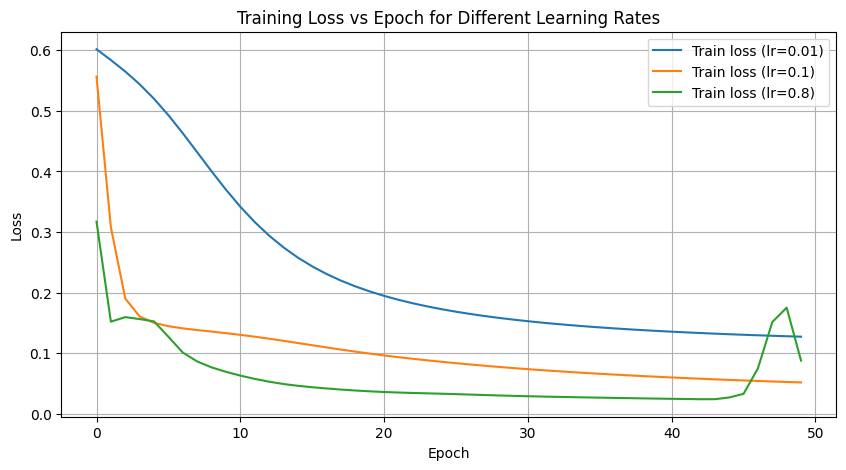

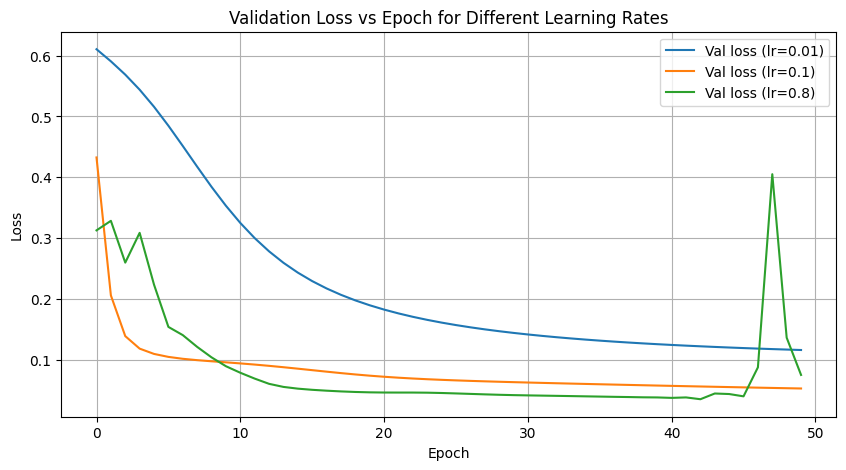


=== Part D: Momentum experiments ===

=== Momentum = 0.0 ===

=== Momentum = 0.9 ===


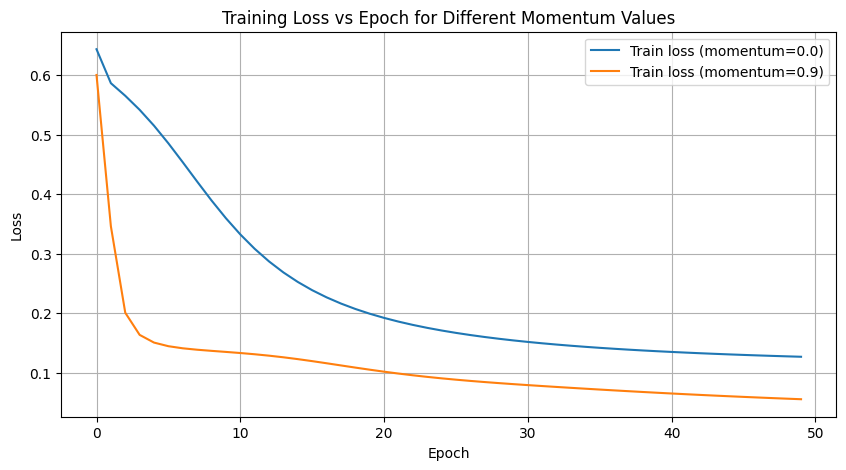

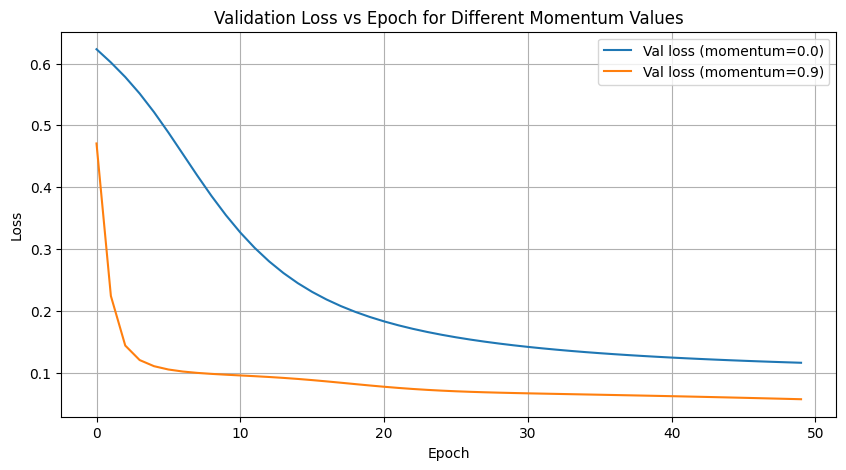


=== Parts E–J: Hidden units, performance, MSE, confusion, F1, learning curves ===

=== Hidden units = 4 ===
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step
Hidden units: 4
  Train acc: 0.9863, Test acc: 0.9913
  Train MSE: 0.0125, Test MSE: 0.0106
  Train F1: 0.9770, Test F1: 0.9863
  Train Confusion Matrix:
 [[959  16]
 [  3 404]]
  Test Confusion Matrix:
 [[235   0]
 [  3 108]]

=== Hidden units = 16 ===
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step
Hidden units: 16
  Train acc: 0.9906, Test acc: 0.9855
  Train MSE: 0.0094, Test MSE: 0.0109
  Train F1: 0.9842, Test F1: 0.9772
  Train Confusion Matrix:
 [[964  11]
 [  2 405]]
  Test Confusion Matrix:
 [[234   1]
 [  4 107]]

=== Hidden units = 64 ===
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step
Hidden units: 64
  Train acc: 0.9899, Test acc: 0.9884
  Train MSE: 0.0092, Test MSE: 0.0090
  Train F1: 0.9831, Test F1: 0.9817
  Train

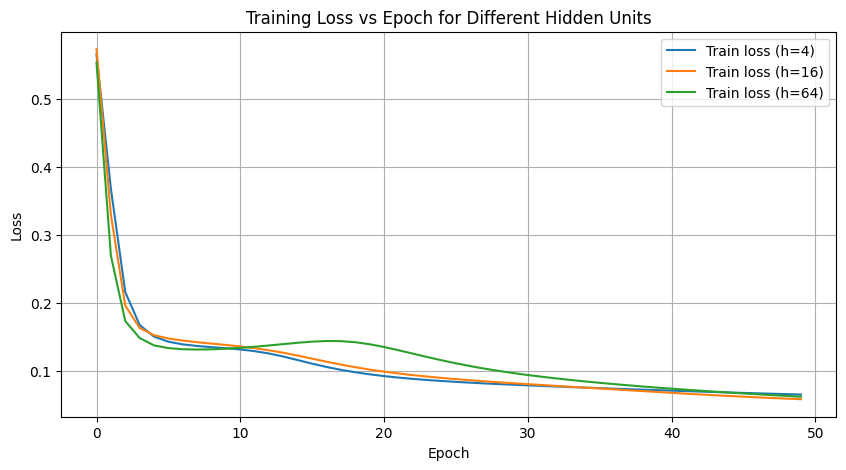

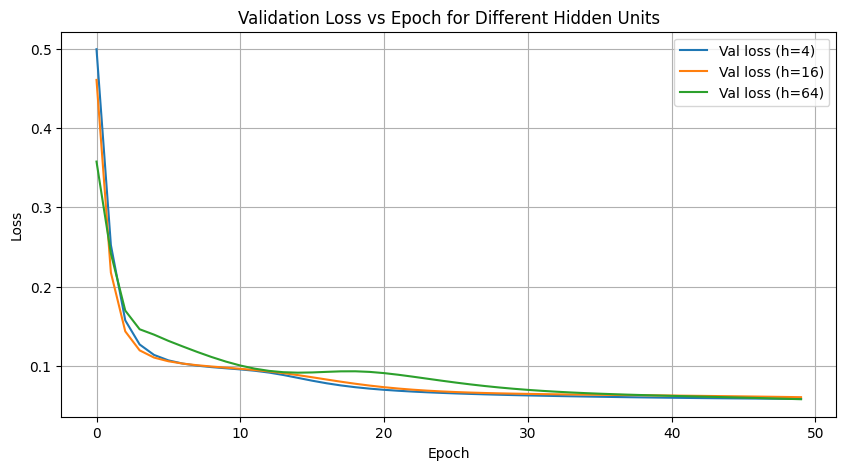


=== Done. Use these results to write Section K (discussion of findings). ===


In [13]:
# ============================================================
# Main: run all experiments (A–J)
# ============================================================

if __name__ == "__main__":
    print("=== Part C: Learning rate experiments ===")
    lr_histories = experiment_learning_rates()

    print("\n=== Part D: Momentum experiments ===")
    momentum_histories = experiment_momentum()

    print("\n=== Parts E–J: Hidden units, performance, MSE, confusion, F1, learning curves ===")
    hidden_results = experiment_hidden_units()

    # K. You will use the printed metrics and plots to write your findings
    print("\n=== Done. Use these results to write Section K (discussion of findings). ===")
